<a href="https://colab.research.google.com/github/rizalrfli/PCVK_GANJIL-2026/blob/main/Praktikum_Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Mengubah tingkat kecerahan citra 
----------------------------------
Masukkan nilai kecerahan: 50


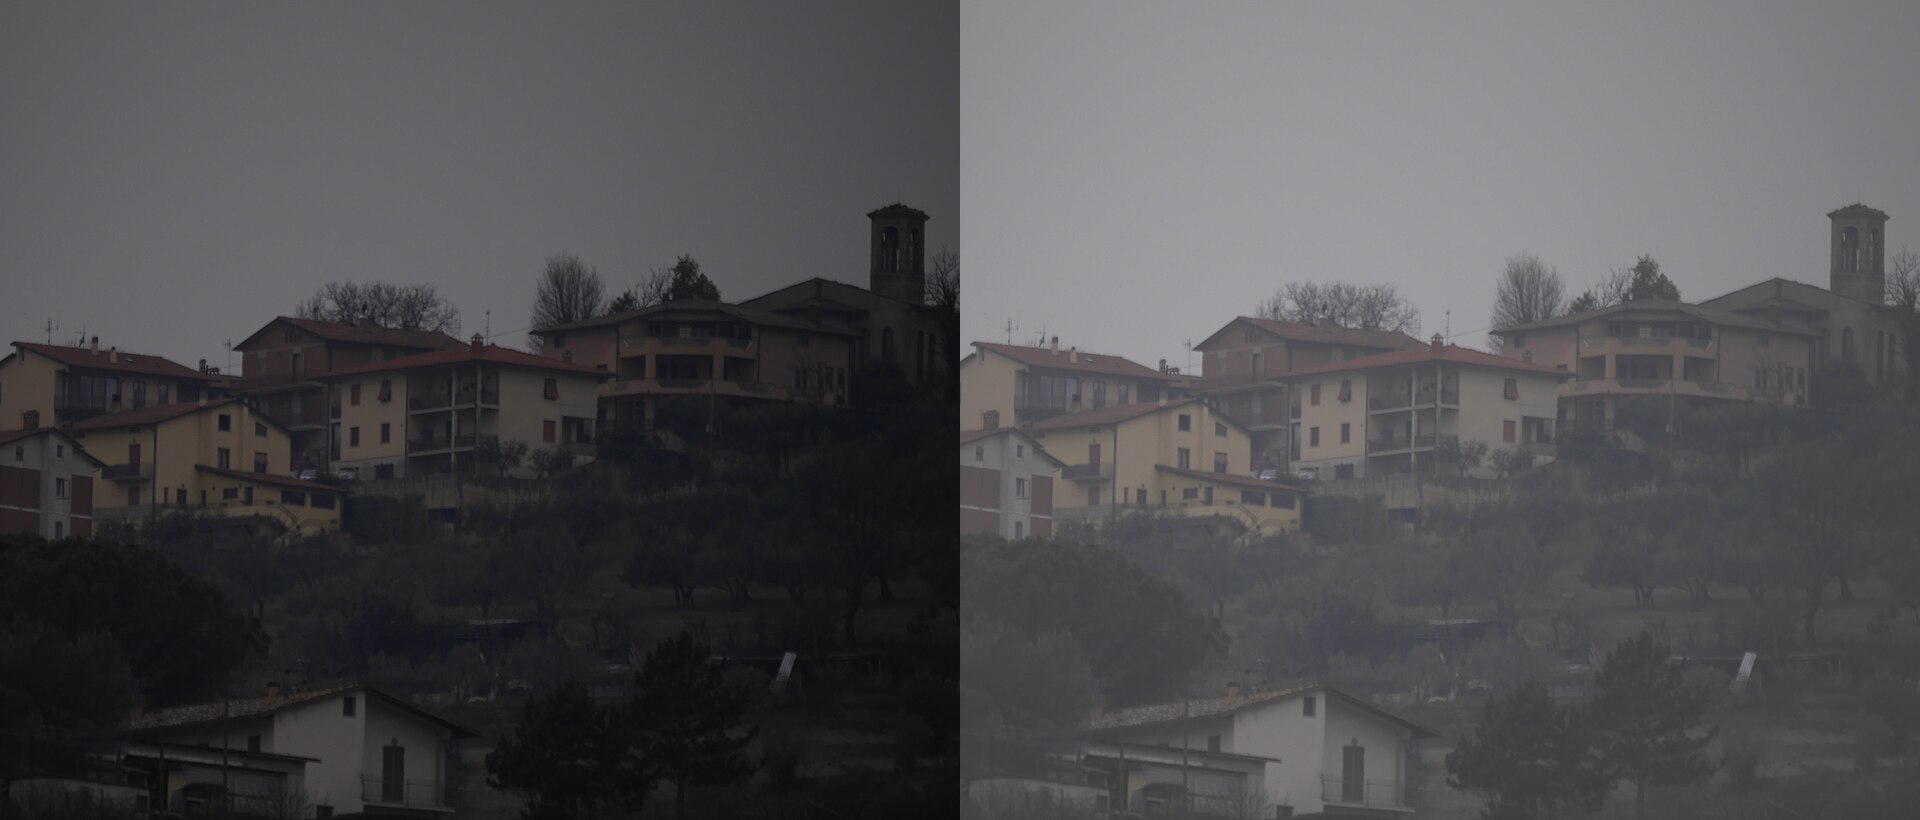

In [1]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

print(' Mengubah tingkat kecerahan citra ')
print('----------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

#sesuaikan dengan file dan folder di drive Anda
original = cv.imread('houses.jpg')
brightness_image = np.zeros(original.shape, original.dtype)

#akses per piksel
#np.clip digunakan untuk melakukan truncate pixel (nilai dibatasi antara 0-255)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

#cara simple tanpa for loop
#brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

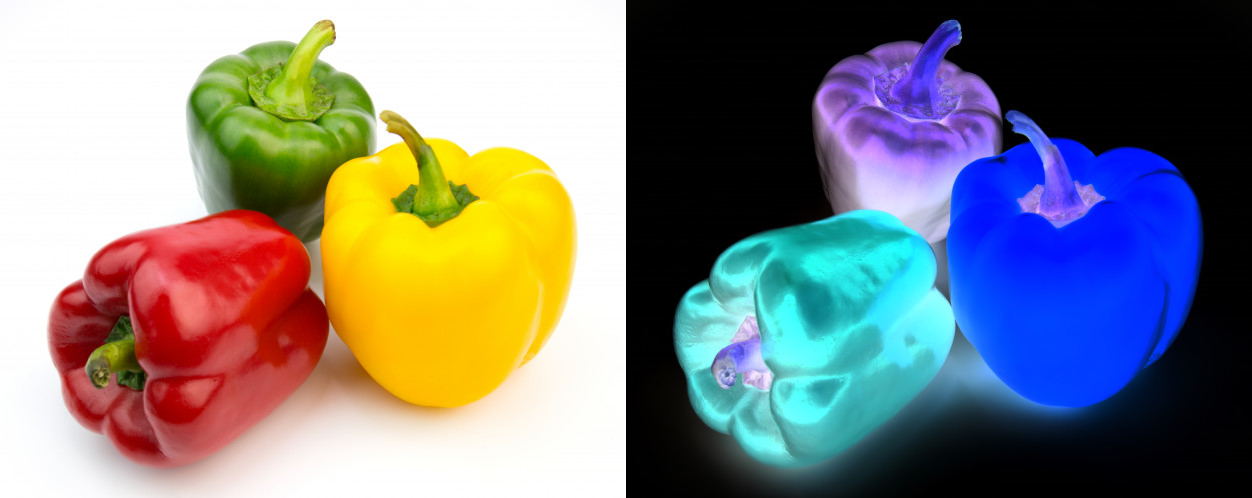

In [ ]:

# Sesuaikan path dengan lokasi gambar Anda di Google Drive
original = cv.imread('peppers.jpg')

# Melakukan operasi inverse citra
# Formula umumnya adalah (L-1) - r, di mana L-1 = 255 untuk citra 8-bit
inverse_image = 255 - original

# Alternatif menggunakan fungsi bawaan OpenCV:
# inverse_image = cv2.bitwise_not(original)

# Menggabungkan gambar agar tampil berdampingan
final_frame = cv.hconcat((original, inverse_image))

# Menampilkan hasil
cv2_imshow(final_frame)

Mengubah kontras dan tingkat kecerahan citra
------------------------------------------------
Masukkan tingkat kecerahan : 10
Masukkan kontras : 1.5


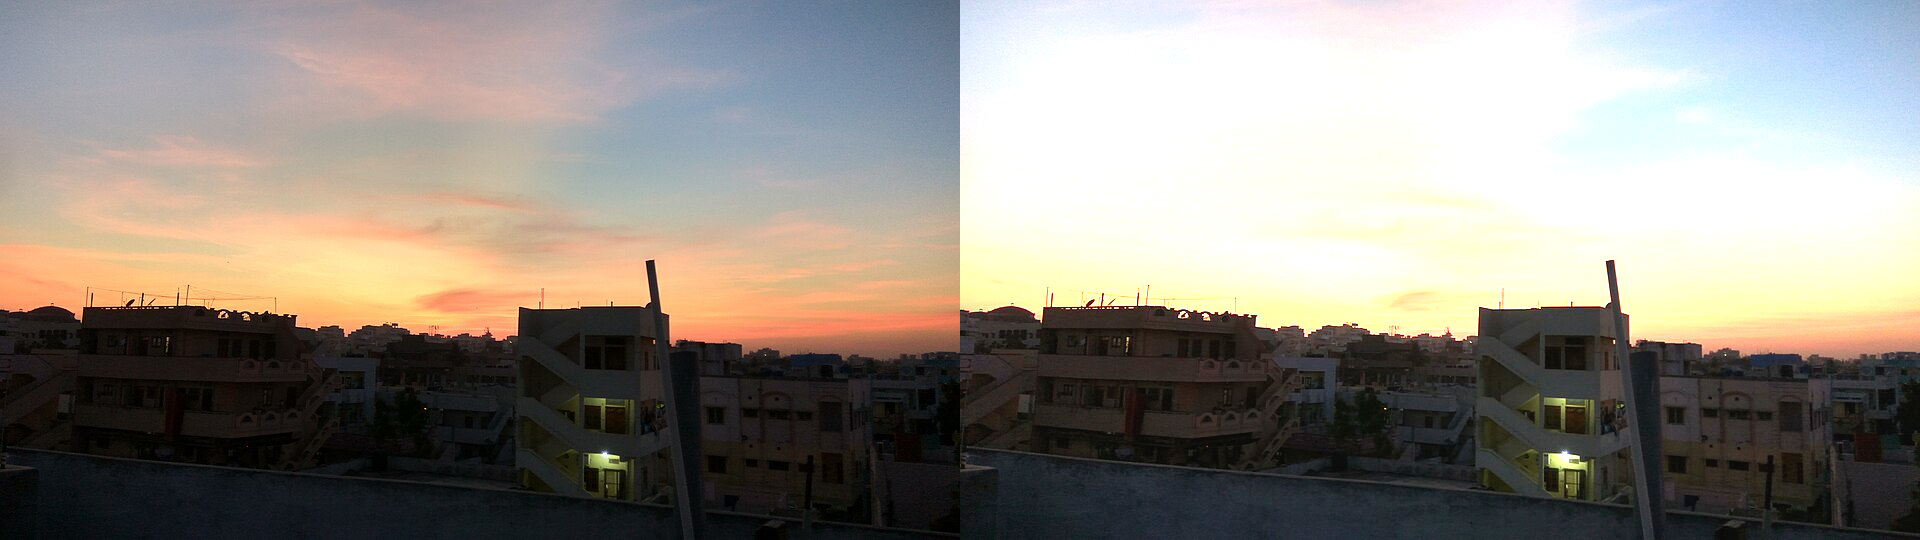

In [ ]:
print('Mengubah kontras dan tingkat kecerahan citra')
print('------------------------------------------------')
try:
    brightness = int(input('Masukkan tingkat kecerahan : '))
    contrast = float(input('Masukkan kontras : '))
except ValueError:
    print('Error, input tidak valid')

# Sesuaikan path file dengan gambar Anda di Google Drive
original = cv.imread('sunset.jpg')

# Membuat matriks kosong untuk menampung citra hasil
result_image = np.zeros(original.shape, original.dtype)

# Cara 1: Mengakses per piksel menggunakan perulangan (Sesuai gaya kode dasar)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            # Terapkan formula dan gunakan np.clip agar nilai tidak melebihi batas 0-255
            kalkulasi = contrast * original[y,x,c] + brightness
            result_image[y,x,c] = np.clip(kalkulasi, 0, 255)

# -------------------------------------------------------------------------
# Cara 2: Lebih singkat dan jauh lebih cepat tanpa for loop (menggunakan fungsi bawaan OpenCV)
# Silakan hapus tanda '#' di bawah ini jika ingin menggunakan cara yang lebih optimal
# result_image = cv2.convertScaleAbs(original, alpha=contrast, beta=brightness)
# -------------------------------------------------------------------------

# Menggabungkan gambar secara horizontal untuk perbandingan
final_frame = cv.hconcat((original, result_image))

# Menampilkan hasil
cv2_imshow(final_frame)

 Mengubah tingkat kecerahan citra 
----------------------------------
Masukkan nilai kecerahan: 50


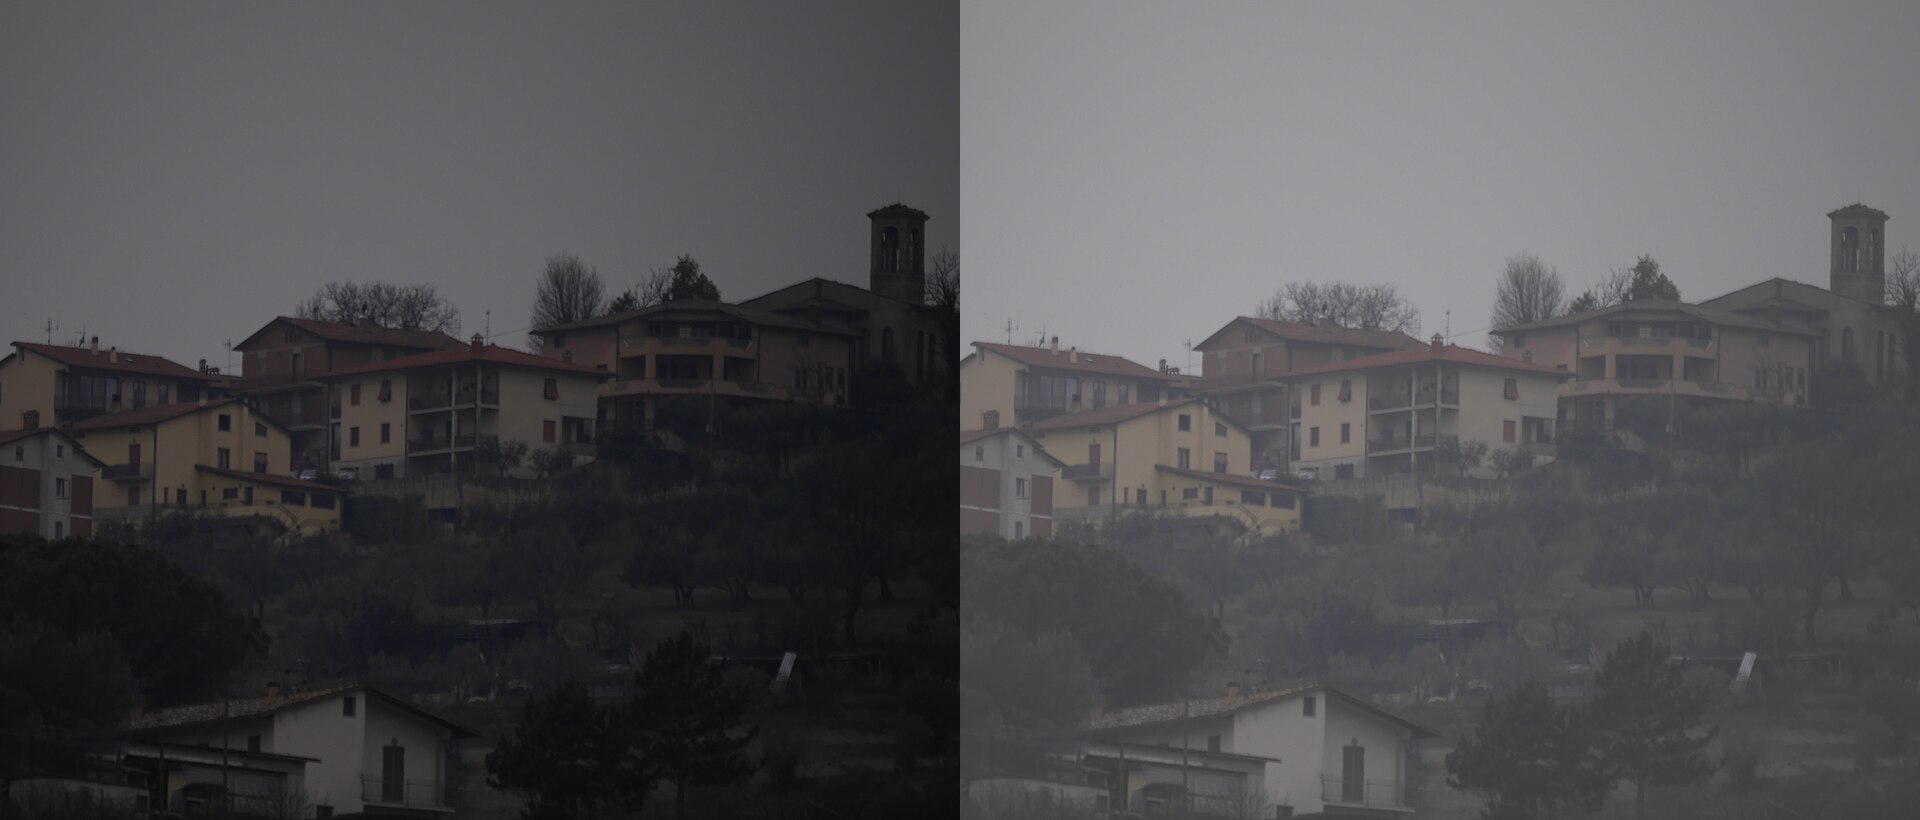

In [ ]:

print(' Mengubah tingkat kecerahan citra ')
print('----------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

#sesuaikan dengan file dan folder di drive Anda
original = cv.imread('houses.jpg')
brightness_image = np.zeros(original.shape, original.dtype)

#akses per piksel
#np.clip digunakan untuk melakukan truncate pixel (nilai dibatasi antara 0-255)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

#cara simple tanpa for loop
#brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)


a. Averaging


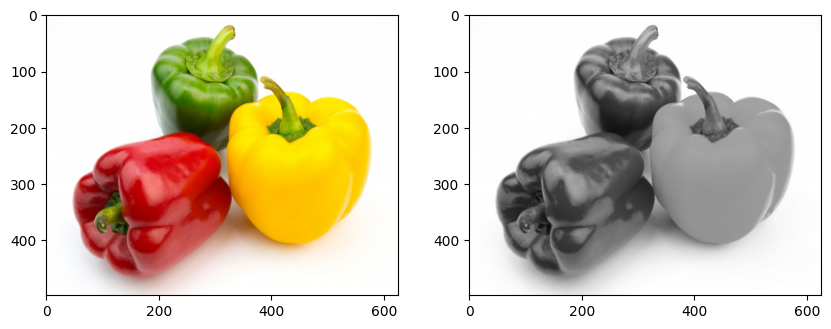


b. Lightness


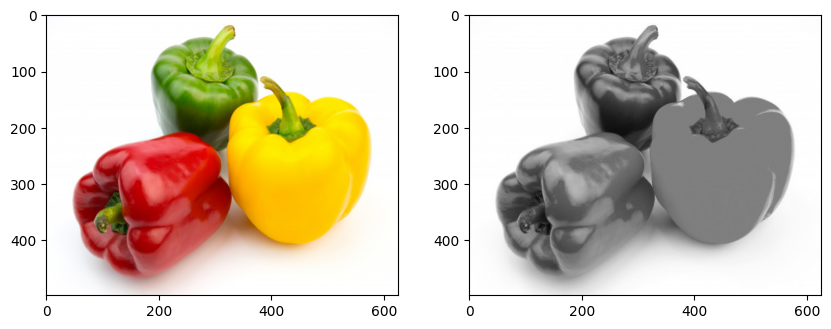


c. Luminance


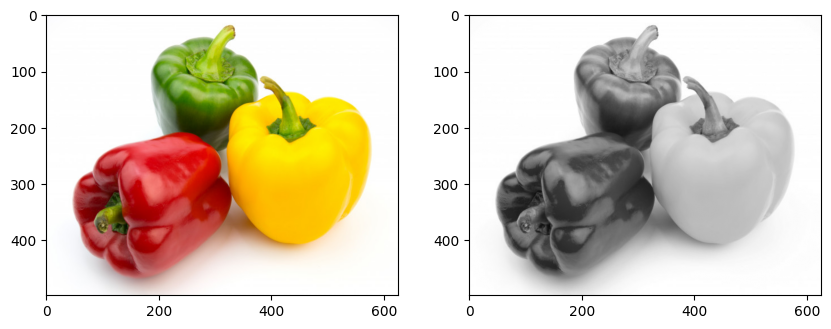

In [ ]:
import matplotlib.pyplot as plt

# 1. Baca Citra (Pastikan path sesuai dengan lokasi gambar di Google Drive Anda)
# Misal: img = cv2.imread('/content/drive/MyDrive/peppers.jpg')
img = cv.imread('peppers.jpg')

# Konversi BGR (format default OpenCV) ke RGB untuk matplotlib
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Pisahkan channel R, G, B
# Di-cast ke float32 untuk menghindari overflow (nilai > 255) saat proses perhitungan
R = img_rgb[:,:,0].astype(np.float32)
G = img_rgb[:,:,1].astype(np.float32)
B = img_rgb[:,:,2].astype(np.float32)

# a. Metode Averaging
# Formula: (R + G + B) / 3
gray_avg = (R + G + B) / 3
gray_avg = np.clip(gray_avg, 0, 255).astype(np.uint8)

# b. Metode Lightness
# Formula: (max(R, G, B) + min(R, G, B)) / 2
max_rgb = np.maximum(np.maximum(R, G), B)
min_rgb = np.minimum(np.minimum(R, G), B)
gray_lightness = (max_rgb + min_rgb) / 2
gray_lightness = np.clip(gray_lightness, 0, 255).astype(np.uint8)

# c. Metode Luminance
# Formula: 0.299*R + 0.587*G + 0.114*B
gray_luminance = (0.299 * R) + (0.587 * G) + (0.114 * B)
gray_luminance = np.clip(gray_luminance, 0, 255).astype(np.uint8)

# --- Fungsi untuk menampilkan hasil seperti pada soal ---
def tampilkan_plot(judul, citra_asli, citra_gray):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    # Plot citra asli
    ax[0].imshow(citra_asli)
    ax[0].set_xticks([0, 200, 400, 600])
    ax[0].set_yticks([0, 100, 200, 300, 400])

    # Plot citra grayscale
    ax[1].imshow(citra_gray, cmap='gray', vmin=0, vmax=255)
    ax[1].set_xticks([0, 200, 400, 600])
    ax[1].set_yticks([0, 100, 200, 300, 400])

    print(f"\n{judul}")
    plt.show()

# Menampilkan hasil
tampilkan_plot("a. Averaging", img_rgb, gray_avg)
tampilkan_plot("b. Lightness", img_rgb, gray_lightness)
tampilkan_plot("c. Luminance", img_rgb, gray_luminance)


5. Selective Color (Merah)


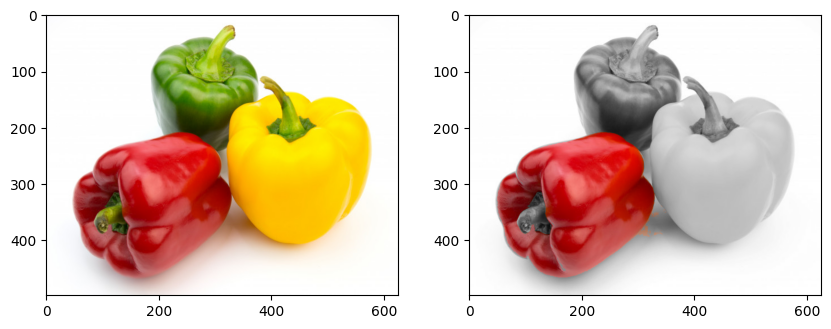

In [ ]:
# Konversi citra asli (BGR) ke HSV untuk memudahkan deteksi warna
img_hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)

# Menentukan batas rentang warna merah pada HSV
# Warna merah pada HSV berada di dua ujung (0-10 dan 170-180)
lower_red1 = np.array([0, 100, 50])
upper_red1 = np.array([10, 255, 255])
mask1 = cv.inRange(img_hsv, lower_red1, upper_red1)

lower_red2 = np.array([170, 100, 50])
upper_red2 = np.array([180, 255, 255])
mask2 = cv.inRange(img_hsv, lower_red2, upper_red2)

# Gabungkan kedua mask merah
mask_red = mask1 | mask2

# Siapkan citra background grayscale (kita gunakan hasil luminance dari soal no 4)
# Karena citra RGB memiliki 3 channel, kita ubah grayscale menjadi 3 channel agar bisa digabungkan
gray_3_channel = cv.cvtColor(gray_luminance, cv.COLOR_GRAY2RGB)

# Proses penggabungan: Jika piksel adalah merah (mask == 255), ambil dari citra asli,
# Jika tidak, ambil dari citra grayscale
hasil_selective = np.where(mask_red[:, :, None] == 255, img_rgb, gray_3_channel)

# Menampilkan hasil
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(img_rgb)
ax[0].set_xticks([0, 200, 400, 600])
ax[0].set_yticks([0, 100, 200, 300, 400])

ax[1].imshow(hasil_selective)
ax[1].set_xticks([0, 200, 400, 600])
ax[1].set_yticks([0, 100, 200, 300, 400])

print("\n5. Selective Color (Merah)")
plt.show()

In [8]:
# Membaca citra
img = cv.imread('houses.jpg')

# Mengubah format warna BGR menjadi RGB
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
print(' Gamma Correction pada citra ')
print('----------------------------------')
try:
    gamma = int(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')

 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 5


 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 0.5


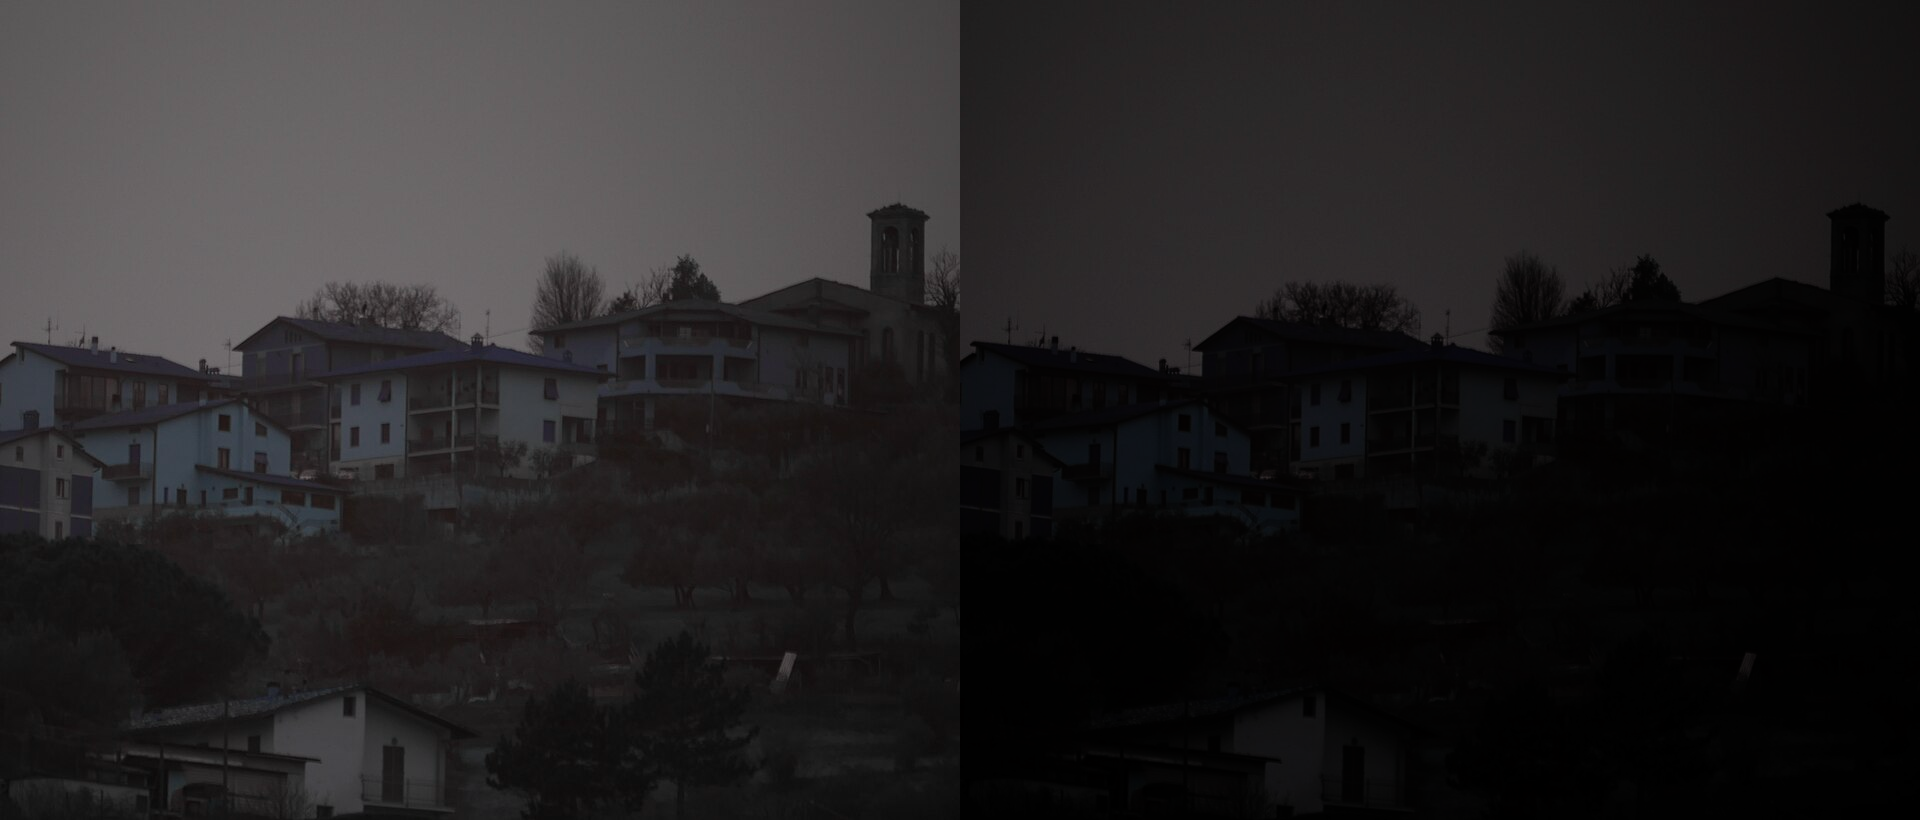

In [9]:
print(' Gamma Correction pada citra ')
print('----------------------------------')
try:
    # Gamma value can be a float, so use float() instead of int()
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')

# Membaca citra
img = cv.imread('houses.jpg')

# Mengubah format warna BGR menjadi RGB
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Buat tabel lookup untuk transformasi gamma
# Normalisasi piksel ke rentang 0-1, terapkan gamma, lalu skala kembali ke 0-255
inverse_gamma = 1.0 / gamma
lookup_table = np.array([((i / 255.0) ** inverse_gamma) * 255 for i in np.arange(0, 256)]).astype('uint8')

# Terapkan transformasi gamma menggunakan lookup table
gamma_corrected_image = cv.LUT(img_rgb, lookup_table)

# Menggabungkan gambar agar tampil berdampingan (asli vs. gamma corrected)
final_frame_gamma = cv.hconcat((img_rgb, gamma_corrected_image))

# Menampilkan hasil
cv2_imshow(final_frame_gamma)

In [14]:
bit_depth=2
level = 255 / (pow(2,bit_depth)-1)
original = cv.imread('peppers.jpg', cv.IMREAD_GRAYSCALE)
depth_image = np.zeros(original.shape, original.dtype)

In [20]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr

# ==========================================
# 1. Membaca citra asli dan citra noise
# ==========================================
img_asli = cv.imread('galaxy.jpg')
noise_img = cv.imread('noisy2.png')

# Resize noise agar sama dengan ukuran galaxy
noise_img = cv.resize(
    noise_img,
    (img_asli.shape[1], img_asli.shape[0])
)

# Ubah noise menjadi grayscale
noise_gray = cv.cvtColor(noise_img, cv.COLOR_BGR2GRAY)

# Normalisasi noise
noise_gray = noise_gray.astype(np.float32)

# Membuat noise dengan rata-rata 0
noise_gray = noise_gray - np.mean(noise_gray)

print("Ukuran galaxy :", img_asli.shape)
print("Ukuran noise  :", noise_gray.shape)

Ukuran galaxy : (256, 310, 3)
Ukuran noise  : (256, 310)


In [21]:
# ==========================================
# 2. Membuat 100 citra noisy
# ==========================================

cv_img = []

for i in range(100):

    # Mengacak posisi noise agar setiap citra berbeda
    noise_random = np.roll(
        noise_gray,
        shift=np.random.randint(0, noise_gray.shape[0]),
        axis=0
    )

    noise_random = np.roll(
        noise_random,
        shift=np.random.randint(0, noise_gray.shape[1]),
        axis=1
    )

    # Ubah menjadi 3 channel
    noise_3channel = cv.merge([
        noise_random,
        noise_random,
        noise_random
    ])

    # Intensitas noise
    noisy = img_asli.astype(np.float32) + noise_3channel * 0.4

    noisy = np.clip(noisy, 0, 255).astype(np.uint8)

    cv_img.append(noisy)

print("Jumlah citra noisy =", len(cv_img))

Jumlah citra noisy = 100


In [22]:
# ==========================================
# 3. Fungsi Average Denoising
# ==========================================

def average_denoising(images, jumlah):

    total = np.zeros_like(
        images[0],
        dtype=np.float64
    )

    for i in range(jumlah):
        total += images[i].astype(np.float64)

    hasil = total / jumlah

    return np.clip(
        hasil,
        0,
        255
    ).astype(np.uint8)

In [23]:
# ==========================================
# 4. Proses averaging
# ==========================================

avg10 = average_denoising(cv_img, 10)
avg20 = average_denoising(cv_img, 20)
avg40 = average_denoising(cv_img, 40)
avg80 = average_denoising(cv_img, 80)
avg100 = average_denoising(cv_img, 100)

In [24]:
# ==========================================
# 5. Menghitung PSNR
# ==========================================

psnr10 = psnr(img_asli, avg10, data_range=255)
psnr20 = psnr(img_asli, avg20, data_range=255)
psnr40 = psnr(img_asli, avg40, data_range=255)
psnr80 = psnr(img_asli, avg80, data_range=255)
psnr100 = psnr(img_asli, avg100, data_range=255)

print("\nHASIL PSNR")
print("==========================")
print(f"10 citra  : {psnr10:.2f} dB")
print(f"20 citra  : {psnr20:.2f} dB")
print(f"40 citra  : {psnr40:.2f} dB")
print(f"80 citra  : {psnr80:.2f} dB")
print(f"100 citra : {psnr100:.2f} dB")


HASIL PSNR
10 citra  : 30.85 dB
20 citra  : 33.24 dB
40 citra  : 34.34 dB
80 citra  : 34.29 dB
100 citra : 34.85 dB


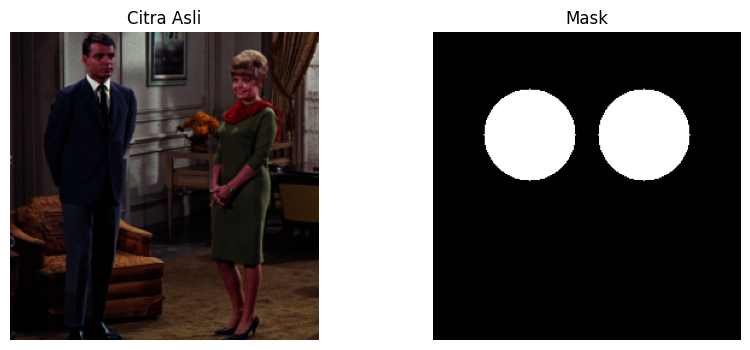

In [25]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Membaca citra
img = cv.imread('couple.tiff')

# Convert BGR ke RGB untuk matplotlib
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Membuat mask hitam dengan ukuran sama seperti citra
mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)

# Membuat 2 lingkaran putih
# Lingkaran kiri
cv.circle(mask, (80, 85), 38, 255, -1)

# Lingkaran kanan
cv.circle(mask, (175, 85), 38, 255, -1)

# Menampilkan citra asli dan mask
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(mask, cmap='gray')
plt.title('Mask')
plt.axis('off')

plt.show()

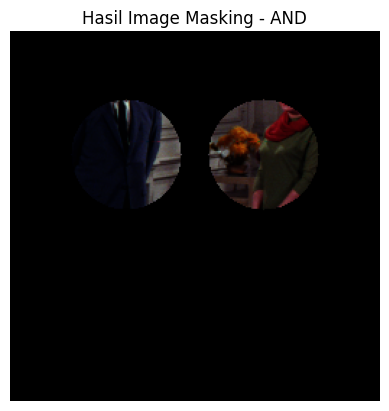

In [26]:
hasil_and = cv.bitwise_and(img, img, mask=mask)

plt.imshow(cv.cvtColor(hasil_and, cv.COLOR_BGR2RGB))
plt.title('Hasil Image Masking - AND')
plt.axis('off')
plt.show()

NOT

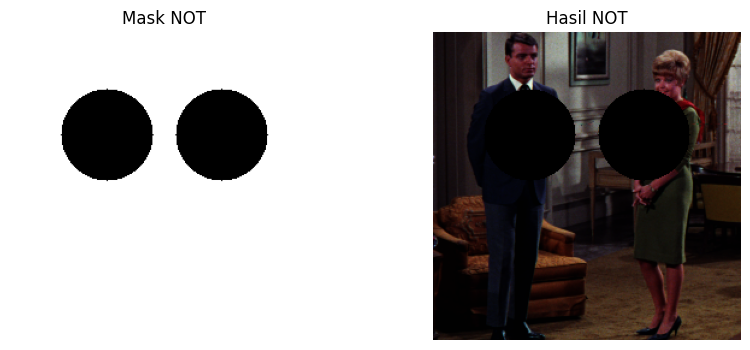

In [27]:
mask_not = cv.bitwise_not(mask)

hasil_not = cv.bitwise_and(img, img, mask=mask_not)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(mask_not, cmap='gray')
plt.title('Mask NOT')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(hasil_not, cv.COLOR_BGR2RGB))
plt.title('Hasil NOT')
plt.axis('off')

plt.show()

OR

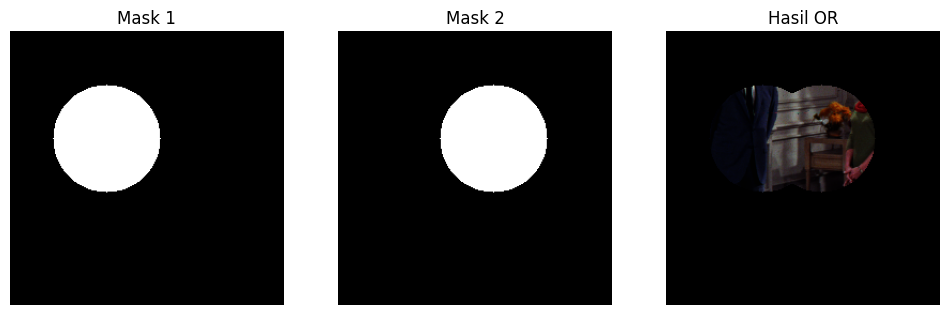

In [28]:
mask1 = np.zeros((256,256), dtype=np.uint8)
mask2 = np.zeros((256,256), dtype=np.uint8)

cv.circle(mask1, (90, 100), 50, 255, -1)
cv.circle(mask2, (145, 100), 50, 255, -1)

mask_or = cv.bitwise_or(mask1, mask2)

hasil_or = cv.bitwise_and(img, img, mask=mask_or)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(mask1, cmap='gray')
plt.title('Mask 1')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(mask2, cmap='gray')
plt.title('Mask 2')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv.cvtColor(hasil_or, cv.COLOR_BGR2RGB))
plt.title('Hasil OR')
plt.axis('off')

plt.show()

AND

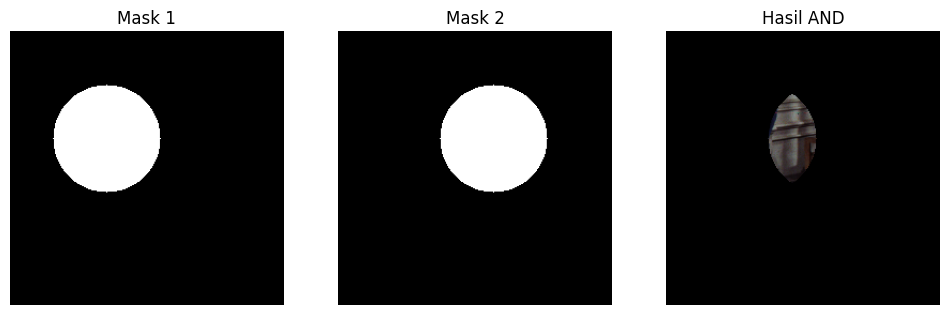

In [29]:
mask_and = cv.bitwise_and(mask1, mask2)

hasil_and2 = cv.bitwise_and(img, img, mask=mask_and)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(mask1, cmap='gray')
plt.title('Mask 1')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(mask2, cmap='gray')
plt.title('Mask 2')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv.cvtColor(hasil_and2, cv.COLOR_BGR2RGB))
plt.title('Hasil AND')
plt.axis('off')

plt.show()

NAND

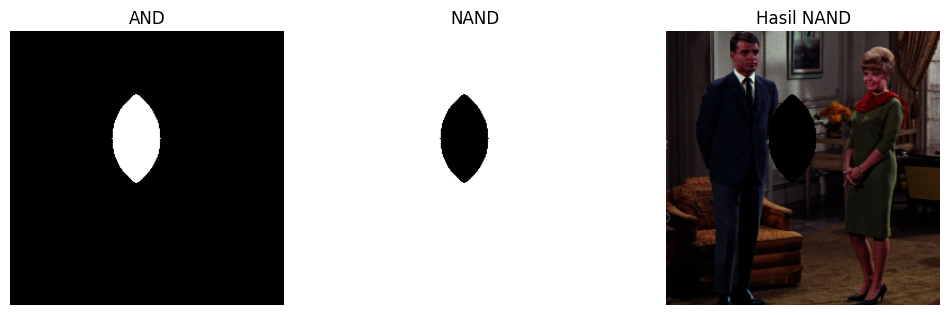

In [30]:
mask_and = cv.bitwise_and(mask1, mask2)

mask_nand = cv.bitwise_not(mask_and)

hasil_nand = cv.bitwise_and(img, img, mask=mask_nand)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(mask_and, cmap='gray')
plt.title('AND')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(mask_nand, cmap='gray')
plt.title('NAND')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv.cvtColor(hasil_nand, cv.COLOR_BGR2RGB))
plt.title('Hasil NAND')
plt.axis('off')

plt.show()

XOR

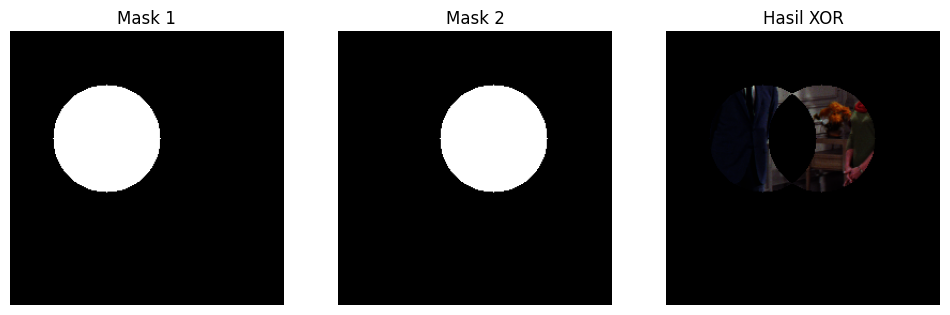

In [31]:
mask_xor = cv.bitwise_xor(mask1, mask2)

hasil_xor = cv.bitwise_and(img, img, mask=mask_xor)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(mask1, cmap='gray')
plt.title('Mask 1')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(mask2, cmap='gray')
plt.title('Mask 2')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv.cvtColor(hasil_xor, cv.COLOR_BGR2RGB))
plt.title('Hasil XOR')
plt.axis('off')

plt.show()

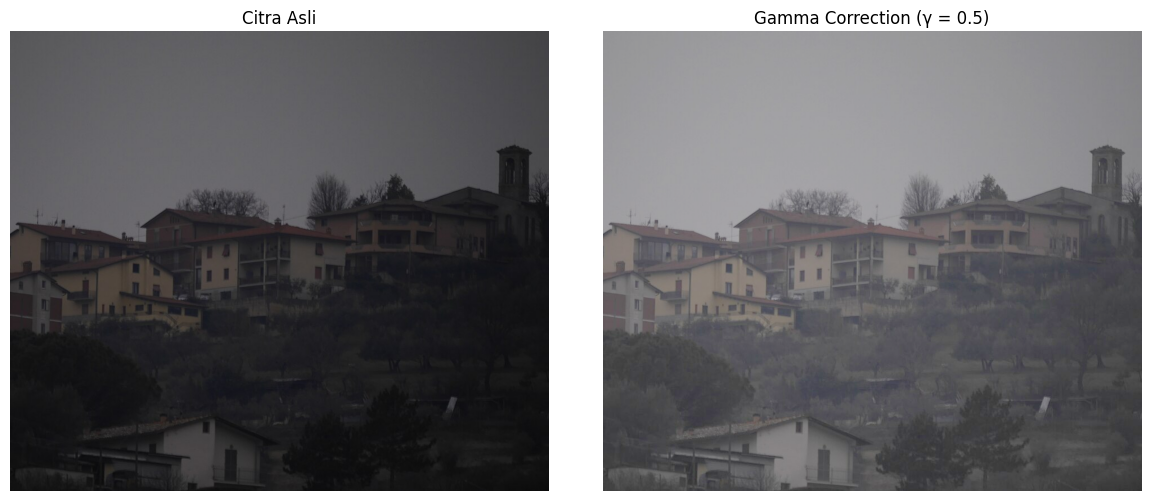

In [32]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Membaca gambar
img = cv.imread('houses.jpg')

# Convert BGR ke RGB
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Nilai gamma
gamma = 0.5

# Normalisasi pixel 0-255 menjadi 0-1
normal = img_rgb / 255.0

# Gamma Correction
hasil = np.power(normal, gamma)

# Kembalikan ke rentang 0-255
hasil = np.uint8(hasil * 255)

# Menampilkan hasil
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hasil)
plt.title(f'Gamma Correction (γ = {gamma})')
plt.axis('off')

plt.tight_layout()
plt.show()

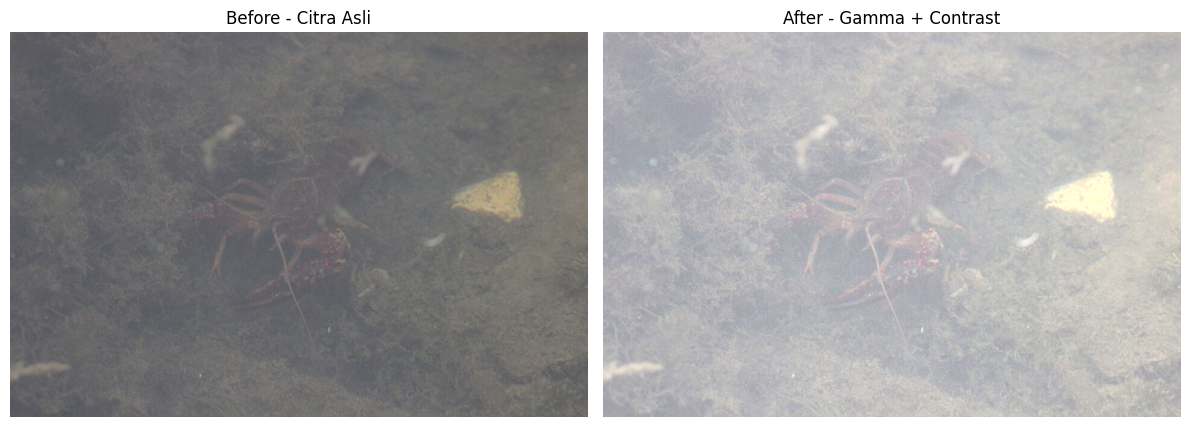

In [33]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Membaca citra
# ==========================================
img = cv.imread('crayfish.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# ==========================================
# 2. Gamma Correction
# ==========================================
gamma = 0.7

normal = img_rgb / 255.0
gamma_img = np.power(normal, gamma)
gamma_img = np.uint8(gamma_img * 255)

# ==========================================
# 3. Contrast Enhancement
# ==========================================
alpha = 1.5   # contrast
beta = -20    # brightness adjustment

hasil = cv.convertScaleAbs(
    gamma_img,
    alpha=alpha,
    beta=beta
)

# ==========================================
# 4. Menampilkan Before - After
# ==========================================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Before - Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hasil)
plt.title('After - Gamma + Contrast')
plt.axis('off')

plt.tight_layout()
plt.show()